# **EQUIPO LFM** | Aprendizaje automatico

## Bibliotecas a utilizar en el cuaderno

In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ShuffleSplit, cross_val_score

## Funciones

In [507]:
# @title
# funciones

# Optimización de K: Error vs. Número de Vecinos
def koptimomse(X_train, X_test, y_train, y_test):
  k_values = range(1, 21) # Probamos k desde 1 hasta 20
  errores_mse = []

  for k in k_values:
      # Entrenar modelo con el k actual
      modelo = KNeighborsRegressor(n_neighbors=k)
      modelo.fit(X_train, y_train)

      # Predecir y calcular el error
      predicciones = modelo.predict(X_test)
      mse = mean_squared_error(y_test, predicciones)
      errores_mse.append(mse)

  # Guardar resultados y graficar
  resultados = pd.DataFrame({'k': k_values, 'MSE': errores_mse})

  plt.figure(figsize=(10, 6))
  plt.plot(k_values, errores_mse, marker='o', linestyle='--', color='darkblue')

  # Estética del gráfico
  plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
  plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
  plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
  plt.xticks(k_values) # Para ver todos los números del 1 al 20
  plt.grid(True, alpha=0.3)

  # Marcar el punto óptimo
  min_mse = min(errores_mse)
  best_k = k_values[errores_mse.index(min_mse)]
  plt.annotate(f'K óptimo = {best_k}',
              xy=(best_k, min_mse),
              xytext=(best_k + 1, min_mse + 0.01),
              arrowprops=dict(facecolor='black', shrink=0.05))

  plt.show()
  print(f"El valor de K óptimo es: {best_k}")
  return best_k

# Optimización de K: R2 vs. Número de Vecinos
def koptimor2(X_train, X_test, y_train, y_test):
  k_values = range(1, 21) # Probamos k desde 1 hasta 20
  errores_r2 = []

  for k in k_values:
      # Entrenar modelo con el k actual
      modelo = KNeighborsRegressor(n_neighbors=k)
      modelo.fit(X_train, y_train)

      # Predecir y calcular el error
      predicciones = modelo.fit(X_train, y_train).predict(X_test)
      r2 = r2_score(y_test, predicciones)
      errores_r2.append(r2)

  # Guardar resultados y graficar
  resultados = pd.DataFrame({'k': k_values, 'MSE': errores_r2})

  plt.figure(figsize=(10, 6))
  plt.plot(k_values, errores_r2, marker='o', linestyle='--', color='darkblue')

  # Estética del gráfico
  plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
  plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
  plt.ylabel('R2 Score (R2)', fontsize=12)
  plt.xticks(k_values) # Para ver todos los números del 1 al 20
  plt.grid(True, alpha=0.3)

  # Marcar el punto óptimo
  max_r2 = max(errores_r2)
  best_k = k_values[errores_r2.index(max_r2)]
  plt.annotate(f'K óptimo = {best_k}',
              xy=(best_k, max_r2),
              xytext=(best_k + 1, max_r2 + 0.01),
              arrowprops=dict(facecolor='black', shrink=0.05))

  plt.show()


# Grafico de regresion con resultados
def regre(y_test, y_pred):
  # 1. Cálculo de métricas
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  return mse, r2


# Grafico de regresion con resultados
def regrapho(y_test, y_pred):
  # 1. Cálculo de métricas
  mse, r2 = regre(y_test, y_pred)
#  mse = mean_squared_error(y_test, y_pred)
#  r2 = r2_score(y_test, y_pred)

  # 2. Generación del gráfico
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

  # Configuración de etiquetas
  plt.xlabel('Valores Reales')
  plt.ylabel('Predicciones')
  plt.title('Real vs Predicho (KNN Regressor)')

  # 3. Agregar el cuadro de texto "dentro" del gráfico (esquina inferior derecha)
  texto_metricas = f"MSE: {mse:.4f}\nR²: {r2:.4f}"

  # Usamos plt.gca().text para posicionar el texto
  # transform=plt.gca().transAxes asegura que (1,0) sea la esquina inferior derecha exacta
  plt.gca().text(0.95, 0.05, texto_metricas,
                transform=plt.gca().transAxes,
                fontsize=11,
                verticalalignment='bottom',
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='teal'))

  plt.show()
  print(f"Mean Square Error: {mse}")
  print(f"R^2: {r2}")
  return mse, r2





## Data acquisition - Creación de un dataframe a partir del archivo csv

In [466]:
dfIris = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSLgU6YF5djPgcJvcmXyqdIjfVefPsYlj6HUnRH15sZwsEL4GX7KPY-c3CWgM3n8vCljid-ZPocdAAl/pub?output=csv')

## Preprocesamiento

### Feature Scaling
- No se hace uso de un StandardScaler o MinMaxScaler para unificar las escalas porque en el dataset estas ya estan informadas en la misma escala (centímetros).

### Header standarization & data cleaning

- Renombraremos las columnas al español, y eliminaremos la columan Id ya que no será utilizada para el análisis

In [467]:
#Renombrado de columnas
dfIris.rename({'SepalLengthCm':'sepalo_largo',
           'SepalWidthCm':'sepalo_ancho',
           'PetalLengthCm':'petalo_largo',
           'PetalWidthCm':'petalo_ancho',
           'Species':'especies'},
          axis=1, inplace=True) # inplace = True para que el renombrado sea sobre el mismo df

dfIris.drop('Id', axis=1, inplace=True) #axis=1 indica que es una columna


Inspección de la forma del df

In [468]:
dfIris.shape

(150, 5)

Visualización del segmento inicial y final de los datos

In [469]:
dfIris

,sepalo_largo,sepalo_ancho,petalo_largo,petalo_ancho,especies
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Matriz de Correlación

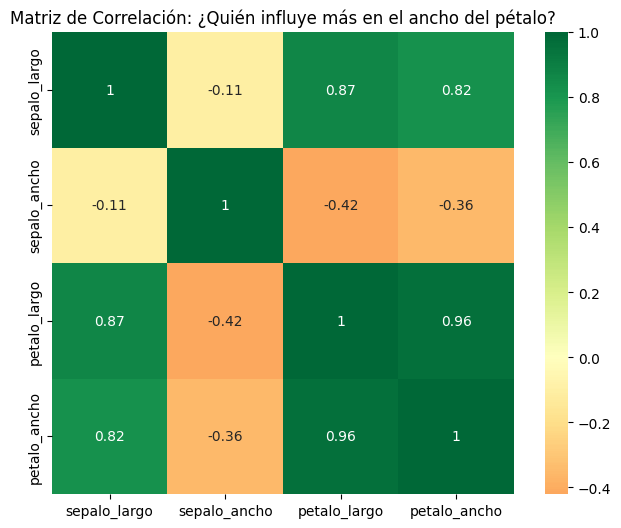

In [470]:
# 1. Calculamos la correlación de las columnas numéricas
matriz_corr = dfIris.drop(columns=['especies']).corr()

# 2. Generamos el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', center=0, square=True)

plt.title('Matriz de Correlación: ¿Quién influye más en el ancho del pétalo?')
plt.show()

### Conclusiones parciales:

- Largo del pétalo: Según se observa en la matriz de correlación es la variable con mayor correlación.
- Largo del sépalo: Esta variable también tiene una alta correlación con el ancho del petalo.
- Ancho del sépalo: Esta variable tiene una correlación muy baja e incluso negativa.

Estas correlaciones analíticas tienen coherencia biológica, dado que los petalos crecen en ambas direcciones, a lo largo y a lo ancho. A su vez, los sépalos (cáliz, exterior) y pétalos (corola, interior) son hojas modificadas que forman el perianto que tiene una función de protección de los organos sexuales y de atracción de polinizadores y en el desarrollo temprano del capullo, los sépalos actúan como cobertura protectora del pétalo.

## Estudio de impacto de la dimensionalidad en los entrenamientos

Se procede a entrenar modelos con cantidades diferentes sucesivas de dimensiones y evaluar su rendimiento.



## Tres dimensiones

- Largo del pétalo
- Largo del sépalo
- Ancho del sépalo



### Particionamiento

In [471]:
X3 = dfIris.drop(['petalo_ancho', 'especies'], axis=1)
y = dfIris['petalo_ancho']

In [472]:
# 2. División en entrenamiento y prueba
X_train3, X_test3, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

### Búsqueda de K óptimo - Holdout - K vs MSE

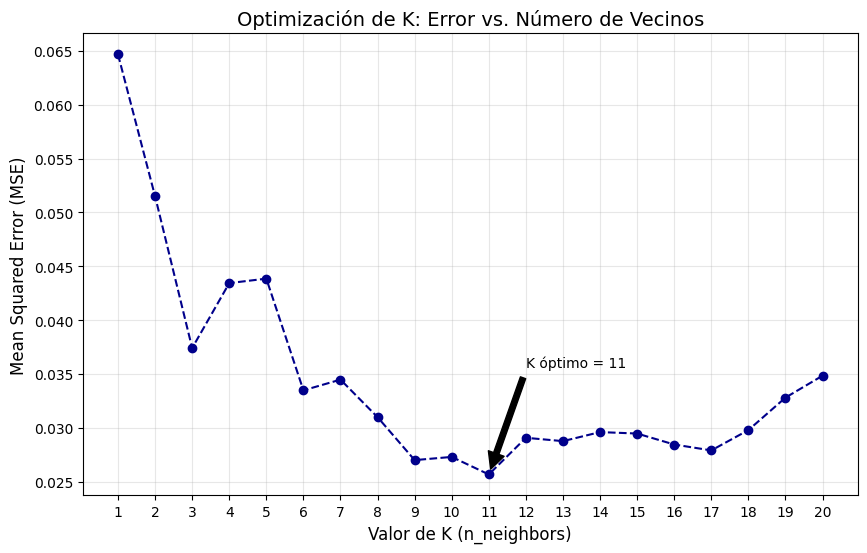

El valor de K óptimo es: 11


In [473]:
best_k3 = koptimomse(X_train3, X_test3, y_train, y_test)

### Búsqueda de K óptimo - Holdout - K vs R^2

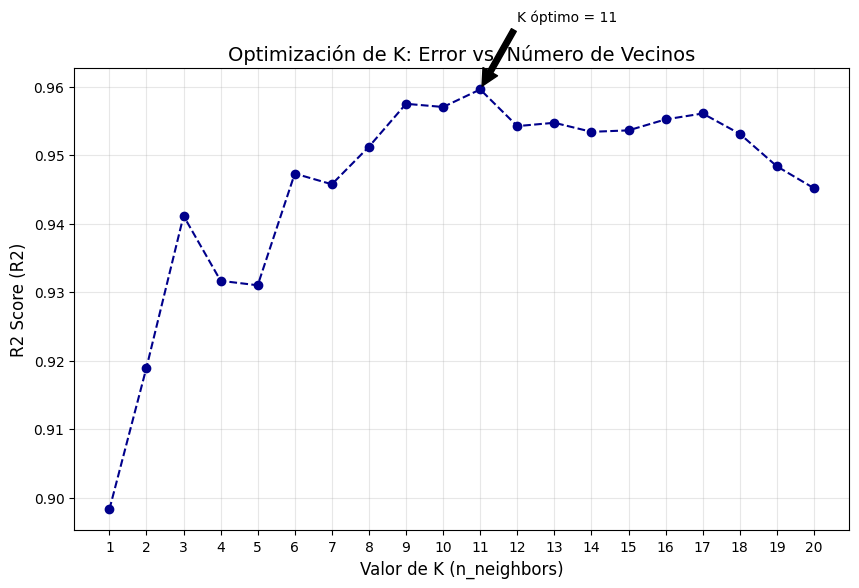

In [474]:
koptimor2(X_train3, X_test3, y_train, y_test)

### Implementación de KNN Regresor

In [475]:
knn = KNeighborsRegressor(n_neighbors=best_k3, p=2, weights='distance')
knn.fit(X_train3, y_train)
X_train3

,sepalo_largo,sepalo_ancho,petalo_largo
22,4.6,3.6,1.0
15,5.7,4.4,1.5
65,6.7,3.1,4.4
11,4.8,3.4,1.6
42,4.4,3.2,1.3
...,...,...,...
71,6.1,2.8,4.0
106,4.9,2.5,4.5
14,5.8,4.0,1.2
92,5.8,2.6,4.0


### Predicciones

In [476]:
y_pred3 = knn.predict(X_test3)

### Evaluación del modelo - Resultados

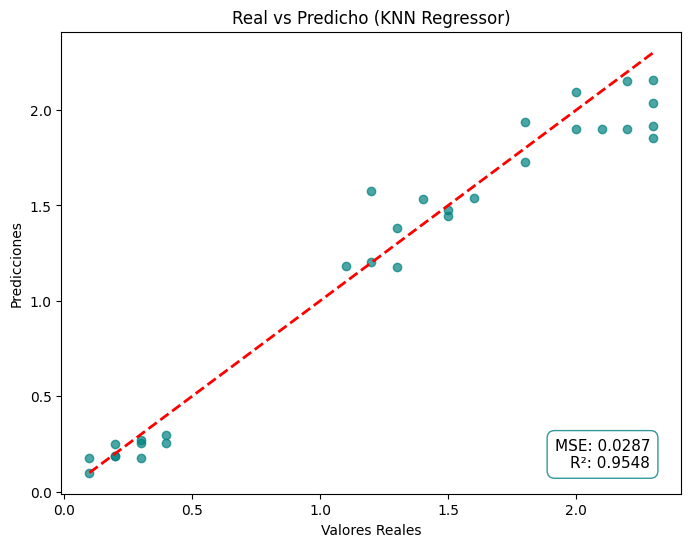

Mean Square Error: 0.02871226282551242
R^2: 0.9548304697810464


In [477]:
mse3, r2_3 = regrapho(y_test, y_pred3)

## Dos dimensiones

- Largo del pétalo
- Ancho del sépalo

#### Particionamiento

In [478]:
X2 = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo'], axis=1)

In [479]:
# 2. División en entrenamiento y prueba
X_train2, X_test2, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

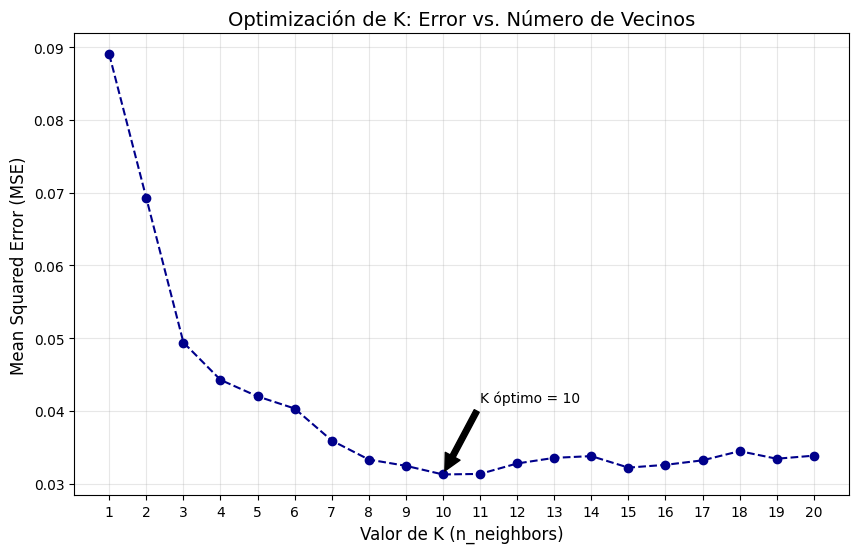

El valor de K óptimo es: 10


In [480]:
best_k2 = koptimomse(X_train2, X_test2, y_train, y_test)

#### Búsqueda de K óptimo - Holdout - K vs R^2

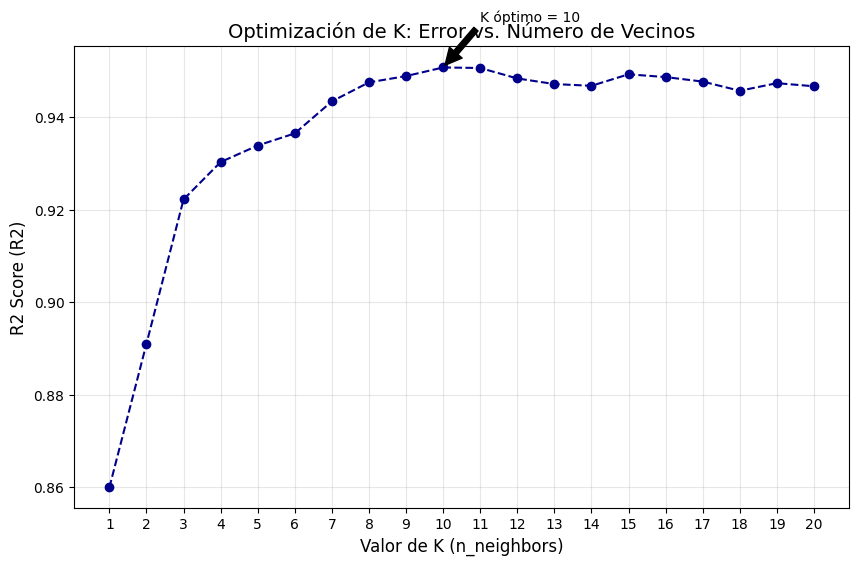

In [481]:
koptimor2(X_train2, X_test2, y_train, y_test)

### Implementación KNN Regressor

In [482]:
knn = KNeighborsRegressor(n_neighbors=best_k2)
knn.fit(X_train2, y_train)

KNeighborsRegressor(n_neighbors=10)

### Predicciones

In [483]:
y_pred2 = knn.predict(X_test2)

### Evaluación del modelo - Resultados



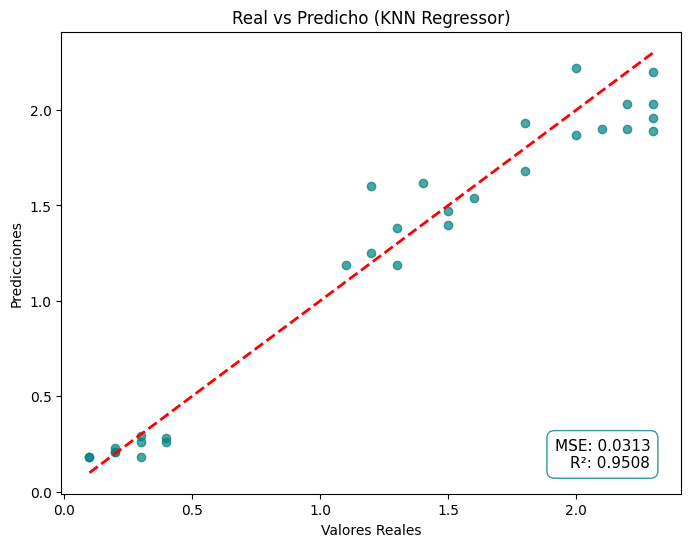

Mean Square Error: 0.03126999999999999
R^2: 0.9508066912548725


In [484]:
mse2, r2_2 = regrapho(y_test, y_pred2)

## Una dimension

- Largo del pétalo

### Particionamiento

In [485]:
X1 = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo', 'sepalo_ancho'], axis=1)

In [486]:
# 2. División en entrenamiento y prueba
X_train1, X_test1, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

### Búsqueda de K óptimo - Holdout - K vs MSE

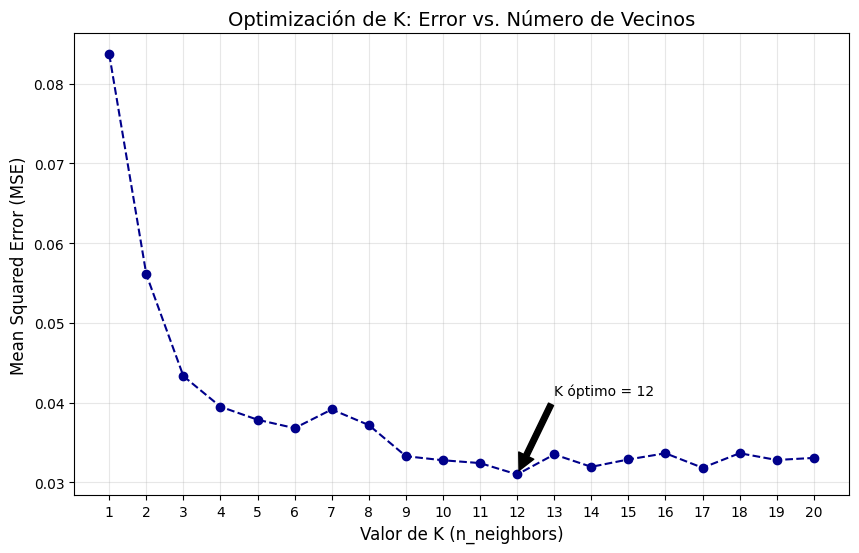

El valor de K óptimo es: 12


In [487]:
best_k1 = koptimomse(X_train1, X_test1, y_train, y_test)

### Búsqueda de K óptimo - Holdout - K vs R2

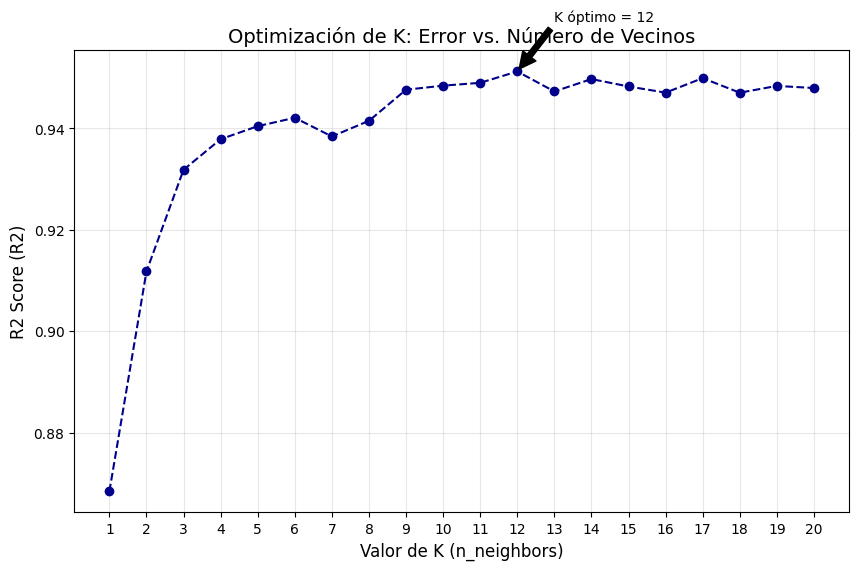

In [488]:
koptimor2(X_train1, X_test1, y_train, y_test)

### Implementación de KNN Regressor

In [489]:
knn = KNeighborsRegressor(n_neighbors=best_k1)
knn.fit(X_train1, y_train)

KNeighborsRegressor(n_neighbors=12)

### Predicciones

In [490]:
y_pred1 = knn.predict(X_test1)

### Evaluación del modelo - Resultados


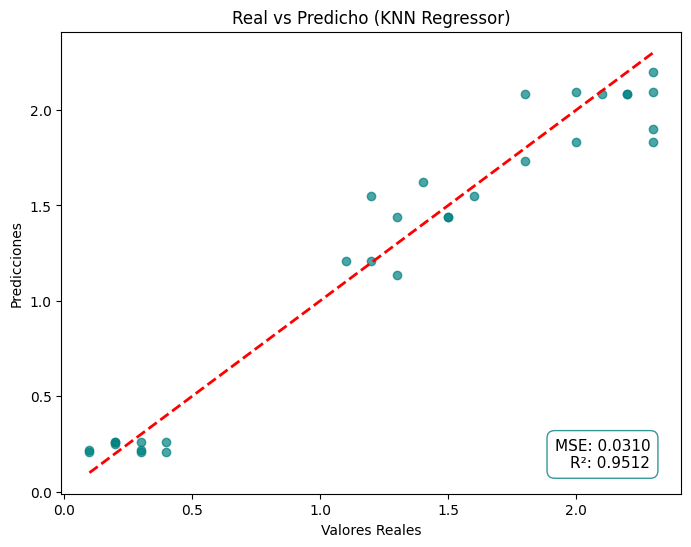

Mean Square Error: 0.03100694444444444
R^2: 0.9512205247426104


In [491]:
mse1, r2_1 = regrapho(y_test, y_pred1)

# Comparaciones

A fin de observar el impacto de la exploración de K óptimos, se procede a obtener los valores de R^2 y MSE para todas las dimensionalidades usando el valor teórico de K acorde al tamaño del dataset (K = 12).

Con todos los datos se crea una tabla para poder realizar las comparaciones correspondientes.

In [508]:
knn = KNeighborsRegressor(n_neighbors=12)

knn.fit(X_train3, y_train)
y_pred_12n_3 = knn.predict(X_test3)
mse_12n_3, r2_12n_3 = regre(y_test, y_pred_12n_3)

knn.fit(X_train2, y_train)
y_pred_12n_2 = knn.predict(X_test2)
mse_12n_2, r2_12n_2 = regre(y_test, y_pred_12n_2)

In [514]:
# Creamos un diccionario con los resultados
data = {
    "Dimensiones": ["1 dimensión", "2 dimensiones", "3 dimensiones"],
    "|": ['|', '|', '|'],
    "K optimo": [best_k1, best_k2, best_k3],
    " ": [' ', ' ', ' '],
    "MSE": [mse1, mse2, mse3],
    "R² Score": [r2_1, r2_2, r2_3],
    "| ": ['| ', '| ', '| '],
    "K teórico": ['12 ', '12 ', '12 '],
    " MSE": [mse1, mse_12n_2, mse_12n_3],
    " R² Score": [r2_1, r2_12n_2, r2_12n_3]

}

# Creamos el DataFrame
df_comparativo = pd.DataFrame(data)

# Imprimimos con un formato estético
print("TABLA COMPARATIVA DE MODELOS")
print("-" * 80)
print(df_comparativo.to_string(index=False))
print("-" * 80)

# Opcional: Si quieres resaltar cuál es el mejor (menor MSE)
mejor_modelo = df_comparativo.loc[df_comparativo['MSE'].idxmin(), 'Dimensiones']
print(f"El mejor desempeño lo tiene el modelo entrenado con: {mejor_modelo}")

TABLA COMPARATIVA DE MODELOS
--------------------------------------------------------------------------------
  Dimensiones |  K optimo        MSE  R² Score |  K teórico      MSE   R² Score
  1 dimensión |        12   0.031007  0.951221 |        12  0.031007   0.951221
2 dimensiones |        10   0.031270  0.950807 |        12  0.032780   0.948431
3 dimensiones |        11   0.028712  0.954830 |        12  0.029076   0.954258
--------------------------------------------------------------------------------
El mejor desempeño lo tiene el modelo entrenado con: 3 dimensiones


# Conclusiones grales:

**El problema de la multi-colinealidad en la multi-dimensinalidad:**

Como KNN calcula distancias en un espacio multidimensional, al agregar dos dimensiones que tienen alta colinealidad (como largo del pétalo y largo del sépalo) esto hace que la información se vuelva redundante y el cálculo de la distancia euclidiana (Minkowski p=2 por defecto en Scikit learn) se vea "arrastrado" doblemente por la misma tendencia subyacente. Asi el algoritmo resulta menos sensible a variables de menor correlación como el ancho del sépalo. Es decir, la predicción termina dependiendo excesivamente de la magnitud de la longitud.